In [8]:
# Check missing values
print(df.isnull().sum())

# Remove duplicates if any
df = df.drop_duplicates()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
average score                  0
dtype: int64


In [9]:
# Create average score
df['average_score'] = df[['math score','reading score','writing score']].mean(axis=1)

# Create performance category
df['performance_level'] = pd.cut(
    df['average_score'],
    bins=[0,50,70,85,100],
    labels=['Low','Medium','High','Excellent']
)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average score,average_score,performance_level
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,72.666667,High
1,female,group C,some college,standard,completed,69,90,88,82.333333,82.333333,High
2,female,group B,master's degree,standard,none,90,95,93,92.666667,92.666667,Excellent
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,49.333333,Low
4,male,group C,some college,standard,none,76,78,75,76.333333,76.333333,High


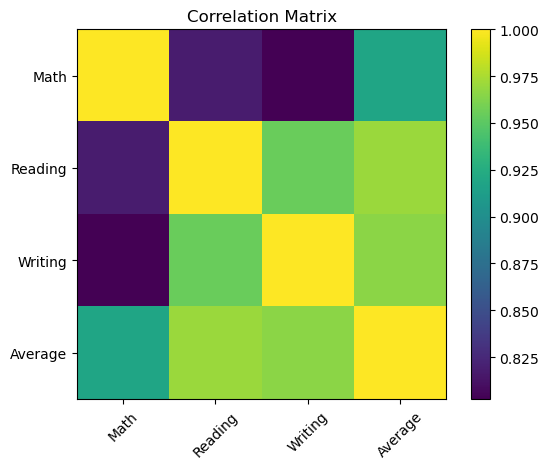

In [10]:
plt.figure()
plt.imshow(df[['math score','reading score','writing score','average_score']].corr())
plt.colorbar()
plt.xticks(range(4), ['Math','Reading','Writing','Average'], rotation=45)
plt.yticks(range(4), ['Math','Reading','Writing','Average'])
plt.title("Correlation Matrix")
plt.show()

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Define predictors and target
X = df[['reading score','writing score']]
y = df['math score']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R² Score: 0.6825697127424625
Mean Squared Error: 77.24297821278957
